# Model Training: Baseline Random Forest Classifier

**Purpose:** Train a baseline Machine Learning model to predict a student's Broad Career Category based on their 11-point personality and interest vector.
**Author:** Nate G. (and AI Assistant)
**Date:** 2024-03-15
**Required Inputs:** `data/processed/Kaggle_Cleaned_Mapped_10_Categories_V2.csv`
**Expected Outputs:** Trained Random Forest model saved to `models/baseline_rf_model.joblib`, along with F1-Score and Confusion Matrix evaluation metrics.

In [2]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the models directory exists for saving later
os.makedirs('../models', exist_ok=True)

In [13]:
def load_and_prep_data(filepath: str) -> tuple[pd.DataFrame, pd.Series]:
    """
    Loads the processed training data and separates features from the target.
    
    Args:
        filepath (str): The path to the cleaned training dataset.
        
    Returns:
        tuple: A tuple containing the feature matrix (X) and the target vector (y).
    """
    try:
        df = pd.read_csv(filepath)
        
        # UPDATED: Only using the 6 RIASEC features
        feature_cols = [
            'R normalized', 'I normalized', 'A normalized', 
            'S normalized', 'E normalized', 'C normalized'
        ]
        
        # UPDATED: Using the exact column name from your new CSV
        target_col = 'Career Category'
        
        # We only want rows where we have both the features and the target category
        df = df.dropna(subset=feature_cols + [target_col])
        
        X = df[feature_cols]
        y = df[target_col]
        
        print(f"✅ Data loaded successfully. Shape: {df.shape}")
        return X, y
        
    except FileNotFoundError as e:
        print(f"❌ Error loading data: {e}")
        raise

# UPDATED: Pointing to the new file name
# Note: Adjust the '../data/processed/' path if you saved it somewhere else in the repo
data_path = '../docs/data/Kaggle_Cleaned_Mapped_Categories.csv'
X, y = load_and_prep_data(data_path)

✅ Data loaded successfully. Shape: (80107, 101)


In [16]:
# You might need to add this import at the top of the cell:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Split the data FIRST (Keep 20% completely hidden for the test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Original Training Students: {len(X_train)}")
print("Original Training Category Distribution:")
print(y_train.value_counts().head(3)) # Just showing the top 3 for comparison

# 2. Apply SMOTE to the Training Data ONLY
# This creates synthetic students so every category has the exact same number of examples
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n✅ SMOTE Applied! New Training Students: {len(X_train_smote)}")
print("New Training Category Distribution (Notice they are exactly equal now!):")
print(y_train_smote.value_counts().head(3))

# 3. Train the Random Forest on the perfectly balanced data
# We don't need class_weight='balanced' anymore because SMOTE did the balancing for us
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

print("\n✅ Model training complete!")

Original Training Students: 64085
Original Training Category Distribution:
Career Category
Psychology & Human Services          13959
Business & Finance                   12055
Arts, Communications & Humanities     9781
Name: count, dtype: int64

✅ SMOTE Applied! New Training Students: 139590
New Training Category Distribution (Notice they are exactly equal now!):
Career Category
Business & Finance       13959
Science & Mathematics    13959
Healthcare & Medicine    13959
Name: count, dtype: int64

✅ Model training complete!


--- Classification Report ---
                                   precision    recall  f1-score   support

Arts, Communications & Humanities       0.30      0.30      0.30      2446
               Business & Finance       0.37      0.41      0.39      3014
                        Education       0.10      0.07      0.08       717
       Engineering & Architecture       0.27      0.30      0.28      1355
            Healthcare & Medicine       0.17      0.14      0.15      1391
              Law & Public Policy       0.05      0.03      0.04       750
      Psychology & Human Services       0.36      0.39      0.37      3490
            Science & Mathematics       0.23      0.24      0.23      1627
                  Social Sciences       0.04      0.03      0.03       497
                  Technology & IT       0.12      0.11      0.12       735

                         accuracy                           0.28     16022
                        macro avg       0.20      0.20      0.20    

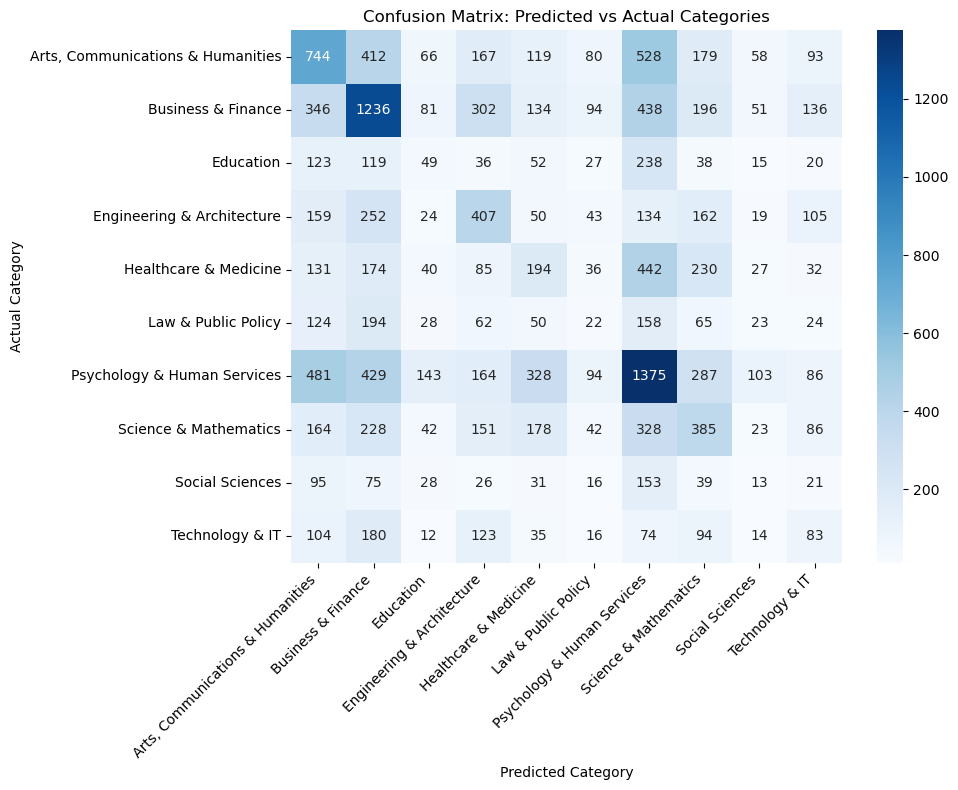

In [18]:
# Make predictions on the 20% test set
y_pred = rf_model.predict(X_test)

# Print the Classification Report (This includes the F1-Scores the professor asked for)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
def save_model(model, filepath: str) -> None:
    """
    Saves a trained machine learning model to disk.
    
    Args:
        model: The trained scikit-learn model.
        filepath (str): The destination path for the saved model.
    """
    try:
        joblib.dump(model, filepath)
        print(f"✅ Model successfully saved to {filepath}")
    except Exception as e:
        print(f"❌ Error saving model: {e}")

# Save the trained model to the models directory
model_save_path = '../models/baseline_rf_model.joblib'
save_model(rf_model, model_save_path)

✅ Model successfully saved to ../models/baseline_rf_model.joblib


In [22]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load your O*NET database (Update path if necessary)
onet_path = os.path.join('..', 'docs', 'data', 'master_careers_riasec_categories.csv')
onet_df = pd.read_csv(onet_path)

def recommend_jobs(student_vector, rf_model, onet_db, top_n_categories=3, top_n_jobs=3):
    """
    The Full Recommendation Pipeline:
    1. ML predicts the Top N broad categories.
    2. Filters O*NET database for jobs in those categories.
    3. Uses Cosine Similarity to find the absolute best specific jobs.
    """
    # 1. Ask the RF Model for the PROBABILITIES of all 10 categories
    # student_vector must be a 2D array, e.g., [[R, I, A, S, E, C]]
    probs = rf_model.predict_proba(student_vector)[0]
    
    # Get the indices of the Top 3 highest probabilities
    top_indices = np.argsort(probs)[-top_n_categories:][::-1]
    
    # Get the actual names of those Top 3 categories
    top_categories = rf_model.classes_[top_indices]
    
    print(f"🤖 ML Model predicted Top {top_n_categories} Categories: {list(top_categories)}")
    
    # 2. Filter the O*NET database to ONLY include jobs from these 3 categories
    filtered_jobs = onet_db[onet_db['Career Category'].isin(top_categories)].copy()
    
    # 3. Calculate Cosine Similarity between the student and these specific jobs
    # We only want the 6 RIASEC columns from the O*NET database for the math
    job_vectors = filtered_jobs[['Realistic', 'Investigative', 'Artistic', 'Social', 'Enterprising', 'Conventional']].values
    
    # calculate similarities
    similarities = cosine_similarity(student_vector, job_vectors)[0]
    
    # Add the scores to our filtered dataframe
    filtered_jobs['Match_Score'] = similarities
    
    # 4. Sort by highest match score and return the Top N jobs
    best_jobs = filtered_jobs.sort_values(by='Match_Score', ascending=False).head(top_n_jobs)
    
    return best_jobs[['Title', 'Career Category', 'Match_Score']]

# ==========================================
# LET'S TEST IT ON A FAKE STUDENT!
# ==========================================
# Imagine a student who is highly Artistic and Social
# Vector format: [Realistic, Investigative, Artistic, Social, Enterprising, Conventional]

test_student_df = pd.DataFrame(
    [[0.1, 0.2, 0.9, 0.8, 0.4, 0.1]], 
    columns=['R normalized', 'I normalized', 'A normalized', 'S normalized', 'E normalized', 'C normalized']
)

# Pass the DataFrame instead of the raw array
results = recommend_jobs(test_student_df, rf_model, onet_df)

print("\n🏆 FINAL TOP 3 JOB RECOMMENDATIONS:")
print(results.to_string(index=False))

🤖 ML Model predicted Top 3 Categories: ['Arts, Communications & Humanities', 'Psychology & Human Services', 'Social Sciences']

🏆 FINAL TOP 3 JOB RECOMMENDATIONS:
                Title                   Career Category  Match_Score
               Actors Arts, Communications & Humanities     0.954040
Musicians and Singers Arts, Communications & Humanities     0.926001
       Choreographers Arts, Communications & Humanities     0.921219


In [23]:
# ==========================================
# TEST STUDENT 2: The "Hands-on Problem Solver"
# ==========================================
# Highly Realistic (likes working with hands/tools) and Investigative (likes science/math)
# Vector: [R, I, A, S, E, C]
student_2_df = pd.DataFrame(
    [[0.9, 0.8, 0.1, 0.2, 0.3, 0.4]], 
    columns=['R normalized', 'I normalized', 'A normalized', 'S normalized', 'E normalized', 'C normalized']
)

results_2 = recommend_jobs(student_2_df, rf_model, onet_df)
print("\n" + "="*40)
print("TEST 2: Highly Realistic & Investigative")
print("="*40)
print(results_2.to_string(index=False))


# ==========================================
# TEST STUDENT 3: The "Corporate Organizer"
# ==========================================
# Highly Enterprising (likes leading/persuading) and Conventional (likes organization/numbers)
# Vector: [R, I, A, S, E, C]
student_3_df = pd.DataFrame(
    [[0.2, 0.1, 0.1, 0.4, 0.9, 0.8]], 
    columns=['R normalized', 'I normalized', 'A normalized', 'S normalized', 'E normalized', 'C normalized']
)

results_3 = recommend_jobs(student_3_df, rf_model, onet_df)
print("\n" + "="*40)
print("TEST 3: Highly Enterprising & Conventional")
print("="*40)
print(results_3.to_string(index=False))

🤖 ML Model predicted Top 3 Categories: ['Engineering & Architecture', 'Science & Mathematics', 'Business & Finance']

TEST 2: Highly Realistic & Investigative
               Title       Career Category  Match_Score
        Hydrologists    Business & Finance     0.981672
Materials Scientists Science & Mathematics     0.977224
   Animal Scientists Science & Mathematics     0.974970
🤖 ML Model predicted Top 3 Categories: ['Business & Finance', 'Arts, Communications & Humanities', 'Social Sciences']

TEST 3: Highly Enterprising & Conventional
                                                              Title    Career Category  Match_Score
                                                     Sales Managers Business & Finance     0.991651
                 First-Line Supervisors of Non-Retail Sales Workers Business & Finance     0.990226
First-Line Supervisors of Office and Administrative Support Workers Business & Finance     0.989496
